In [4]:
# KU Leuven Hydraulic Structures course exercise
# Methodology by Tim Aertsens and Lars Spannan.
#
# Coupling done using
# Capytaine v2.3.1 
# documentation: https://capytaine.org/stable/
#
# Recommended Capytaine references:
# Ancellin and Dias (2019), Capytaine: a Python-based linear potential flow solver.
# Babarit and Delhommeau (2015), Theoretical and numerical aspects of the open source
# BEM solver NEMOH.

# ============================================================
# BLOCK 1 — Imports and global settings
# ============================================================

import os
import logging
import numpy as np
import xarray as xr
import capytaine as cpt
import matplotlib.pyplot as plt

from capytaine.io.legacy import export_hydrostatics

plt.rcParams["figure.figsize"] = (12, 8)

logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s:\t%(message)s"
)

cpt.set_logging("INFO")

In [5]:
# ============================================================
# BLOCK — Convert STL to MAR using Meshmagick
# ============================================================

import os
import subprocess

def run_shell_command(command):
    """
    Run a shell command and print the output.
    Raises an error if the command fails.
    """
    print(f"\nRunning command:\n{command}\n")

    result = subprocess.run(
        command,
        shell=True,
        text=True,
        capture_output=True
    )

    if result.stdout:
        print("STDOUT:")
        print(result.stdout)

    if result.stderr:
        print("STDERR:")
        print(result.stderr)

    if result.returncode != 0:
        raise RuntimeError(
            f"Command failed with return code {result.returncode}:\n{command}"
        )

    return result


# Input STL exported from Gmsh
stl_file = "single_OFPV_mesh.stl"

# Output MAR file for Capytaine/Nemoh format
mar_file = "single_OFPV_mesh.mar"

# Convert STL to MAR
run_shell_command(f"meshmagick -o {mar_file} {stl_file}")

# Check that MAR file was created
if not os.path.isfile(mar_file):
    raise FileNotFoundError(f"Meshmagick did not create the file: {mar_file}")

print(f"Created MAR file: {mar_file}")


Running command:
meshmagick -o single_OFPV_mesh.mar single_OFPV_mesh.stl

STDOUT:

meshmagick - version 3.4
Copyright 2014-2026, Ecole Centrale de Nantes / D-ICE Engineering
single_OFPV_mesh.stl successfully loaded
Writing single_OFPV_mesh.mar
	-> Done.

Meshmagick - version 3.4
Copyright 2014-2026, Ecole Centrale de Nantes / D-ICE Engineering
Maintainer : Francois Rongere <Francois.Rongere@dice-engineering.com>
Good Bye!

Created MAR file: single_OFPV_mesh.mar


In [6]:
# ============================================================
# BLOCK 2 — User inputs
# ============================================================

# ----------------------------
# Mesh file
# ----------------------------
mesh_file = "single_OFPV_mesh.mar"
mesh_file_format = "nemoh"   # Your .mar file from meshmagick is read as Nemoh format

# ----------------------------
# Output folder
# ----------------------------
output_dir = "capytaine_two_body_output"
os.makedirs(output_dir, exist_ok=True)

nc_output_file = os.path.join(output_dir, "two_body_capytaine.nc")
hydrostatics_output_dir = os.path.join(output_dir, "hydrostatics")
os.makedirs(hydrostatics_output_dir, exist_ok=True)

# ----------------------------
# Fluid properties
# ----------------------------
rho = 1025.0       # seawater density [kg/m^3]
g = 9.81           # gravity [m/s^2]
water_depth = 30   # 

# ----------------------------
# Body locations
# ----------------------------
# The original mesh is assumed to be centered at x = 0, y = 0.
# We create two identical bodies separated in x-direction.
#
# Example:
# body_1 center at x = -spacing/2
# body_2 center at x = +spacing/2

body_gap = 5.7
body_width_y = 20.0

body_spacing = body_width_y + body_gap #centertocenter distance

body_1_shift = np.array([0.0, 0.0, 0.0])
body_2_shift = np.array([+body_spacing, 0.0, 0.0])

# ----------------------------
# Centers of mass in LOCAL body coordinates before translation
# ----------------------------
local_center_of_mass = np.array([0.0, 0.0, 4.1])

# ----------------------------
# Frequency and wave heading range
# ----------------------------
T_dense1 = np.linspace(1.0, 15.0, 20)

T_range = np.unique(np.r_[T_dense1])
omega_range = 2.0 * np.pi / T_range

# Wave directions [rad]
# 0 = waves from +x convention depending on Capytaine/WEC-Sim convention;
wave_direction_range = np.linspace(0.0, np.pi / 2.0, 8)

print("Number of frequencies:", len(omega_range))
print("Number of wave directions:", len(wave_direction_range))

# Show the converted MAR mesh using Meshmagick
run_shell_command(f"meshmagick --show {mesh_file}")

Number of frequencies: 20
Number of wave directions: 8

Running command:
meshmagick --show single_OFPV_mesh.mar

STDOUT:

meshmagick - version 3.4
Copyright 2014-2026, Ecole Centrale de Nantes / D-ICE Engineering
single_OFPV_mesh.mar successfully loaded

Meshmagick - version 3.4
Copyright 2014-2026, Ecole Centrale de Nantes / D-ICE Engineering
Maintainer : Francois Rongere <Francois.Rongere@dice-engineering.com>
Good Bye!



CompletedProcess(args='meshmagick --show single_OFPV_mesh.mar', returncode=0, stdout='\n=============================================\nmeshmagick - version 3.4\nCopyright 2014-2026, Ecole Centrale de Nantes / D-ICE Engineering\n=============================================\nsingle_OFPV_mesh.mar successfully loaded\n\n=============================================================\nMeshmagick - version 3.4\nCopyright 2014-2026, Ecole Centrale de Nantes / D-ICE Engineering\nMaintainer : Francois Rongere <Francois.Rongere@dice-engineering.com>\nGood Bye!\n=============================================================\n', stderr='')

In [7]:
# ============================================================
# BLOCK 3 — Load two separate mesh instances
# ============================================================

# Load original mesh once
base_body = cpt.FloatingBody.from_file(mesh_file, file_format=mesh_file_format)
base_mesh = base_body.mesh

# Create two translated copies of the same mesh
mesh_1 = base_mesh.translated(body_1_shift, name="mesh_body_1")
mesh_2 = base_mesh.translated(body_2_shift, name="mesh_body_2")

print(mesh_1)
print(mesh_2)

# ============================================================
# BLOCK 3B — Export two translated bodies and show them in Meshmagick
# ============================================================

from capytaine.io.mesh_writers import write_MAR

body1_left_mar = "body1_left.mar"
body1_right_mar = "body1_right.mar"
two_body_visual_mar = "two_body_visual_check.mar"

# Export translated meshes as MAR files
write_MAR(body1_left_mar, mesh_1.vertices, mesh_1.faces)
write_MAR(body1_right_mar, mesh_2.vertices, mesh_2.faces)

print(f"Saved translated body 1 mesh: {body1_left_mar}")
print(f"Saved translated body 2 mesh: {body1_right_mar}")

# Combine both translated MAR files into one MAR file for Meshmagick viewing
run_shell_command(
    f"meshmagick {body1_left_mar} -cc {body1_right_mar} -o {two_body_visual_mar}"
)

# Show the two-body visual-check mesh in Meshmagick
run_shell_command(
    f"meshmagick --show {two_body_visual_mar}"
)

[10:53:58] INFO     New floating body: FloatingBody(mesh=Mesh(..., name="single_OFPV_mesh.mar_mesh"),              
                    lid_mesh=None, dofs={}, name="single_OFPV_mesh.mar").

Mesh(vertices=[[... 2132 vertices ...]], faces=[[... 4248 faces ...]], name="mesh_body_1")
Mesh(vertices=[[... 2132 vertices ...]], faces=[[... 4248 faces ...]], name="mesh_body_2")
Saved translated body 1 mesh: body1_left.mar
Saved translated body 2 mesh: body1_right.mar

Running command:
meshmagick body1_left.mar -cc body1_right.mar -o two_body_visual_check.mar

STDOUT:

meshmagick - version 3.4
Copyright 2014-2026, Ecole Centrale de Nantes / D-ICE Engineering
body1_left.mar successfully loaded
Concatenate body1_left.mar with body1_right.mar
body1_right.mar successfully loaded
Writing two_body_visual_check.mar
	-> Done.

Meshmagick - version 3.4
Copyright 2014-2026, Ecole Centrale de Nantes / D-ICE Engineering
Maintainer : Francois Rongere <Francois.Rongere@dice-engineering.com>
Good Bye!


Running command:
meshmagick --show two_body_visual_check.mar

STDOUT:

meshmagick - version 3.4
Copyright 2014-2026, Ecole Centrale de Nantes / D-ICE Engineering
two_body_visual_check.mar successf

CompletedProcess(args='meshmagick --show two_body_visual_check.mar', returncode=0, stdout='\n=============================================\nmeshmagick - version 3.4\nCopyright 2014-2026, Ecole Centrale de Nantes / D-ICE Engineering\n=============================================\ntwo_body_visual_check.mar successfully loaded\n\n=============================================================\nMeshmagick - version 3.4\nCopyright 2014-2026, Ecole Centrale de Nantes / D-ICE Engineering\nMaintainer : Francois Rongere <Francois.Rongere@dice-engineering.com>\nGood Bye!\n=============================================================\n', stderr='')

In [8]:
# ============================================================
# BLOCK 4 — Create two FloatingBody objects
# ============================================================

body_1_com = local_center_of_mass + body_1_shift
body_2_com = local_center_of_mass + body_2_shift

body_1 = cpt.FloatingBody(
    mesh=mesh_1,
    name="body_1",
    center_of_mass=body_1_com,
)

body_2 = cpt.FloatingBody(
    mesh=mesh_2,
    name="body_2",
    center_of_mass=body_2_com,
)

# Use each body's own CoG as its rotation center
body_1.rotation_center = body_1_com
body_2.rotation_center = body_2_com

# Add 6 rigid-body DOFs to each body
body_1.add_all_rigid_body_dofs()
body_2.add_all_rigid_body_dofs()

print("Body 1 DOFs:", list(body_1.dofs.keys()))
print("Body 2 DOFs:", list(body_2.dofs.keys()))

[10:54:03] INFO     New floating body: FloatingBody(mesh=Mesh(..., name="mesh_body_1"), lid_mesh=None, dofs={},    
                    center_of_mass=[0.  0.  4.1], name="body_1").

           INFO     New floating body: FloatingBody(mesh=Mesh(..., name="mesh_body_2"), lid_mesh=None, dofs={},    
                    center_of_mass=[25.7  0.   4.1], name="body_2").

           INFO     The rotation dof Roll has been initialized around the point: FloatingBody(...,                 
                    name="body_1").rotation_center = [0.  0.  4.1]

           INFO     The rotation dof Pitch has been initialized around the point: FloatingBody(...,                
                    name="body_1").rotation_center = [0.  0.  4.1]

           INFO     The rotation dof Yaw has been initialized around the point: FloatingBody(...,                  
                    name="body_1").rotation_center = [0.  0.  4.1]

           INFO     The rotation dof Roll has been initialized around the point: FloatingBody(...,                 
                    name="body_2").rotation_center = [25.7  0.   4.1]

           INFO     The rotation dof Pitch has been initialized around the point: FloatingBody(...,                
                    name="body_2").rotation_center = [25.7  0.   4.1]

           INFO     The rotation dof Yaw has been initialized around the point: FloatingBody(...,                  
                    name="body_2").rotation_center = [25.7  0.   4.1]

Body 1 DOFs: ['Surge', 'Sway', 'Heave', 'Roll', 'Pitch', 'Yaw']
Body 2 DOFs: ['Surge', 'Sway', 'Heave', 'Roll', 'Pitch', 'Yaw']


In [9]:
# ============================================================
# BLOCK 5 — MANUAL MASS / INERTIA MATRIX
# ============================================================

def make_manual_inertia_matrix(body, mass, Ixx, Iyy, Izz, Ixy=0.0, Ixz=0.0, Iyz=0.0):
    """
    Creates a 6x6 rigid-body mass/inertia matrix for one body.

    DOF order expected:
    Surge, Sway, Heave, Roll, Pitch, Yaw

    Units:
    mass: kg
    inertias: kg m^2
    """
    dof_names = list(body.dofs.keys())

    M = np.zeros((6, 6), dtype=float)

    # Translational mass block
    M[0, 0] = mass
    M[1, 1] = mass
    M[2, 2] = mass

    # Rotational inertia block
    M[3, 3] = Ixx
    M[4, 4] = Iyy
    M[5, 5] = Izz

    # Products of inertia / rotational coupling
    M[3, 4] = Ixy
    M[4, 3] = Ixy

    M[3, 5] = Ixz
    M[5, 3] = Ixz

    M[4, 5] = Iyz
    M[5, 4] = Iyz

    return xr.DataArray(
        M,
        dims=("influenced_dof", "radiating_dof"),
        coords={
            "influenced_dof": dof_names,
            "radiating_dof": dof_names,
        },
        name="inertia_matrix",
    )


# ----------------------------
# Manual M mass parameters
# ----------------------------
m = 89600

Ixx = 7935000
Iyy = 7935000
Izz = 12069000

Ixy = 0.0
Ixz = 0.0
Iyz = 0.0

# Assign to both bodies
body_1.inertia_matrix = make_manual_inertia_matrix(
    body_1, m, Ixx, Iyy, Izz, Ixy=Ixy, Ixz=Ixz, Iyz=Iyz
)

body_2.inertia_matrix = make_manual_inertia_matrix(
    body_2, m, Ixx, Iyy, Izz, Ixy=Ixy, Ixz=Ixz, Iyz=Iyz
)

print("Body 1 manual inertia matrix:")
with np.printoptions(precision=4, suppress=True):
    print(body_1.inertia_matrix.to_numpy())

print("\nBody 2 manual inertia matrix:")
with np.printoptions(precision=4, suppress=True):
    print(body_2.inertia_matrix.to_numpy())

Body 1 manual inertia matrix:
[[   89600.        0.        0.        0.        0.        0.]
 [       0.    89600.        0.        0.        0.        0.]
 [       0.        0.    89600.        0.        0.        0.]
 [       0.        0.        0.  7935000.        0.        0.]
 [       0.        0.        0.        0.  7935000.        0.]
 [       0.        0.        0.        0.        0. 12069000.]]

Body 2 manual inertia matrix:
[[   89600.        0.        0.        0.        0.        0.]
 [       0.    89600.        0.        0.        0.        0.]
 [       0.        0.    89600.        0.        0.        0.]
 [       0.        0.        0.  7935000.        0.        0.]
 [       0.        0.        0.        0.  7935000.        0.]
 [       0.        0.        0.        0.        0. 12069000.]]


In [10]:
# ============================================================
# BLOCK 6 — HYDROSTATIC STIFFNESS FROM CAPYTAINE
# ============================================================

# This clips at the free surface z = 0.
body_1_immersed = body_1.keep_immersed_part(inplace=False)
body_2_immersed = body_2.keep_immersed_part(inplace=False)

# Re-assign mass/inertia and centers after clipping
body_1_immersed.center_of_mass = body_1.center_of_mass
body_2_immersed.center_of_mass = body_2.center_of_mass

body_1_immersed.rotation_center = body_1.rotation_center
body_2_immersed.rotation_center = body_2.rotation_center

body_1_immersed.inertia_matrix = body_1.inertia_matrix
body_2_immersed.inertia_matrix = body_2.inertia_matrix

# Compute hydrostatic stiffness using Capytaine
body_1_immersed.hydrostatic_stiffness = body_1_immersed.compute_hydrostatic_stiffness(rho=rho, g=g)
body_2_immersed.hydrostatic_stiffness = body_2_immersed.compute_hydrostatic_stiffness(rho=rho, g=g)

print("Body 1 hydrostatic stiffness from Capytaine:")
with np.printoptions(precision=4, suppress=True):
    print(body_1_immersed.hydrostatic_stiffness.to_numpy())

print("\nBody 2 hydrostatic stiffness from Capytaine:")
with np.printoptions(precision=4, suppress=True):
    print(body_2_immersed.hydrostatic_stiffness.to_numpy())

           INFO     Clipping copy_of_body_1 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])

           INFO     Clipping copy_of_body_2 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])

Body 1 hydrostatic stiffness from Capytaine:
[[       0.            0.            0.            0.            0.
         0.    ]
 [       0.            0.            0.            0.            0.
         0.    ]
 [       0.            0.       280449.9037      -25.8899      -37.4947
         0.    ]
 [       0.            0.          -25.8899 17206931.3744     -314.2581
      -412.5445]
 [       0.            0.          -37.4947     -314.2581 17206076.9591
       343.2784]
 [       0.            0.            0.            0.            0.
         0.    ]]

Body 2 hydrostatic stiffness from Capytaine:
[[       0.            0.            0.            0.            0.
         0.    ]
 [       0.            0.            0.            0.            0.
         0.    ]
 [       0.            0.       280449.9037      -25.8899      -37.4947
         0.    ]
 [       0.            0.          -25.8899 17206931.3744     -314.2581
      -412.5445]
 [       0.            0.          -37

In [11]:
# ============================================================
# BLOCK 7 — Join bodies into one hydrodynamic multibody problem
# ============================================================

bodies = [body_1_immersed, body_2_immersed]

two_body = cpt.FloatingBody.join_bodies(*bodies, name="two_body_system")

print("Total number of DOFs:", two_body.nb_dofs)
print("Joined DOFs:")
for dof in two_body.dofs.keys():
    print("  ", dof)

           INFO     New floating body: FloatingBody(mesh=CollectionOfMeshes(..., name="two_body_system_mesh"),     
                    lid_mesh=None, dofs={"copy_of_body_1__Surge": ..., "copy_of_body_1__Sway": ...,                
                    "copy_of_body_1__Heave": ..., "copy_of_body_1__Roll": ..., "copy_of_body_1__Pitch": ...,       
                    "copy_of_body_1__Yaw": ..., "copy_of_body_2__Surge": ..., "copy_of_body_2__Sway": ...,         
                    "copy_of_body_2__Heave": ..., "copy_of_body_2__Roll": ..., "copy_of_body_2__Pitch": ...,       
                    "copy_of_body_2__Yaw": ...}, name="two_body_system").

Total number of DOFs: 12
Joined DOFs:
   copy_of_body_1__Surge
   copy_of_body_1__Sway
   copy_of_body_1__Heave
   copy_of_body_1__Roll
   copy_of_body_1__Pitch
   copy_of_body_1__Yaw
   copy_of_body_2__Surge
   copy_of_body_2__Sway
   copy_of_body_2__Heave
   copy_of_body_2__Roll
   copy_of_body_2__Pitch
   copy_of_body_2__Yaw


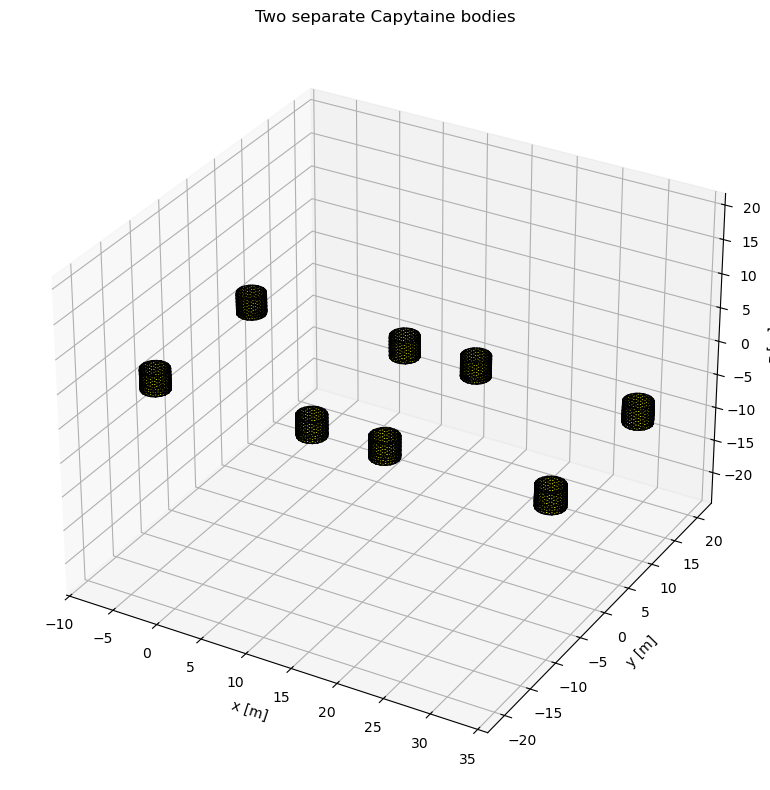

In [12]:
# ============================================================
# BLOCK D — Plot body 1 and body 2 separately
# ============================================================

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

body_1_immersed.mesh.show_matplotlib(ax=ax)
body_2_immersed.mesh.show_matplotlib(ax=ax)

ax.set_title("Two separate Capytaine bodies")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")

# Equal axis scaling
all_vertices = np.vstack([
    body_1_immersed.mesh.vertices,
    body_2_immersed.mesh.vertices,
])

x = all_vertices[:, 0]
y = all_vertices[:, 1]
z = all_vertices[:, 2]

max_range = np.array([
    x.max() - x.min(),
    y.max() - y.min(),
    z.max() - z.min(),
]).max() / 2.0

mid_x = 0.5 * (x.max() + x.min())
mid_y = 0.5 * (y.max() + y.min())
mid_z = 0.5 * (z.max() + z.min())

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "body_1_body_2_position_check.png"), dpi=300)
plt.show()

In [13]:
# ============================================================
# BLOCK 7B — Build combined 12x12 inertia and hydrostatic matrices
# ============================================================

def make_multibody_matrix(joined_body, bodies, matrix_attribute_name):
    """
    Build a full multibody block-diagonal matrix for the joined Capytaine body.

    Example:
        matrix_attribute_name = "inertia_matrix"
        matrix_attribute_name = "hydrostatic_stiffness"

    The individual bodies have DOFs:
        Surge, Sway, Heave, Roll, Pitch, Yaw

    The joined body has DOFs:
        body_1__Surge, body_1__Sway, ...
        body_2__Surge, body_2__Sway, ...

    This function copies each individual 6x6 matrix into the correct
    12x12 block.
    """

    joined_dofs = list(joined_body.dofs.keys())
    n = len(joined_dofs)

    full_matrix = np.zeros((n, n), dtype=float)

    for body in bodies:
        local_matrix = getattr(body, matrix_attribute_name)

        for local_i in local_matrix.coords["influenced_dof"].values:
            for local_j in local_matrix.coords["radiating_dof"].values:

                global_i = f"{body.name}__{local_i}"
                global_j = f"{body.name}__{local_j}"

                i = joined_dofs.index(global_i)
                j = joined_dofs.index(global_j)

                full_matrix[i, j] = float(
                    local_matrix.sel(
                        influenced_dof=local_i,
                        radiating_dof=local_j,
                    )
                )

    return xr.DataArray(
        full_matrix,
        dims=("influenced_dof", "radiating_dof"),
        coords={
            "influenced_dof": joined_dofs,
            "radiating_dof": joined_dofs,
        },
        name=matrix_attribute_name,
    )


# Create full 12x12 matrices
two_body.inertia_matrix = make_multibody_matrix(
    two_body,
    bodies,
    "inertia_matrix",
)

two_body.hydrostatic_stiffness = make_multibody_matrix(
    two_body,
    bodies,
    "hydrostatic_stiffness",
)

print("Combined two-body inertia matrix shape:")
print(two_body.inertia_matrix.shape)

print("\nCombined two-body hydrostatic stiffness matrix shape:")
print(two_body.hydrostatic_stiffness.shape)

Combined two-body inertia matrix shape:
(12, 12)

Combined two-body hydrostatic stiffness matrix shape:
(12, 12)


In [14]:
# ============================================================
# BLOCK A — Print manual mass/inertia matrices
# ============================================================

def print_xarray_matrix(matrix, title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

    row_names = list(matrix.coords["influenced_dof"].values)
    col_names = list(matrix.coords["radiating_dof"].values)
    values = matrix.to_numpy()

    print("Rows    =", row_names)
    print("Columns =", col_names)
    print()

    with np.printoptions(precision=6, suppress=True, linewidth=200):
        print(values)


print_xarray_matrix(body_1_immersed.inertia_matrix, "BODY 1 MANUAL INERTIA MATRIX")
print_xarray_matrix(body_2_immersed.inertia_matrix, "BODY 2 MANUAL INERTIA MATRIX")
print_xarray_matrix(two_body.inertia_matrix, "COMBINED TWO-BODY 12x12 INERTIA MATRIX")


BODY 1 MANUAL INERTIA MATRIX
Rows    = [np.str_('Surge'), np.str_('Sway'), np.str_('Heave'), np.str_('Roll'), np.str_('Pitch'), np.str_('Yaw')]
Columns = [np.str_('Surge'), np.str_('Sway'), np.str_('Heave'), np.str_('Roll'), np.str_('Pitch'), np.str_('Yaw')]

[[   89600.        0.        0.        0.        0.        0.]
 [       0.    89600.        0.        0.        0.        0.]
 [       0.        0.    89600.        0.        0.        0.]
 [       0.        0.        0.  7935000.        0.        0.]
 [       0.        0.        0.        0.  7935000.        0.]
 [       0.        0.        0.        0.        0. 12069000.]]

BODY 2 MANUAL INERTIA MATRIX
Rows    = [np.str_('Surge'), np.str_('Sway'), np.str_('Heave'), np.str_('Roll'), np.str_('Pitch'), np.str_('Yaw')]
Columns = [np.str_('Surge'), np.str_('Sway'), np.str_('Heave'), np.str_('Roll'), np.str_('Pitch'), np.str_('Yaw')]

[[   89600.        0.        0.        0.        0.        0.]
 [       0.    89600.        0.     

In [15]:
# ============================================================
# BLOCK B — Print Capytaine hydrostatic stiffness matrices
# ============================================================

print_xarray_matrix(
    body_1_immersed.hydrostatic_stiffness,
    "BODY 1 HYDROSTATIC STIFFNESS MATRIX FROM CAPYTAINE",
)

print_xarray_matrix(
    body_2_immersed.hydrostatic_stiffness,
    "BODY 2 HYDROSTATIC STIFFNESS MATRIX FROM CAPYTAINE",
)

print_xarray_matrix(
    two_body.hydrostatic_stiffness,
    "COMBINED TWO-BODY 12x12 HYDROSTATIC STIFFNESS MATRIX",
)


BODY 1 HYDROSTATIC STIFFNESS MATRIX FROM CAPYTAINE
Rows    = [np.str_('Surge'), np.str_('Sway'), np.str_('Heave'), np.str_('Roll'), np.str_('Pitch'), np.str_('Yaw')]
Columns = [np.str_('Surge'), np.str_('Sway'), np.str_('Heave'), np.str_('Roll'), np.str_('Pitch'), np.str_('Yaw')]

[[       0.              0.              0.              0.              0.              0.      ]
 [       0.              0.              0.              0.              0.              0.      ]
 [       0.              0.         280449.903705      -25.88989       -37.49469         0.      ]
 [       0.              0.            -25.88989  17206931.374415     -314.258084     -412.544477]
 [       0.              0.            -37.49469      -314.258084 17206076.959069      343.278446]
 [       0.              0.              0.              0.              0.              0.      ]]

BODY 2 HYDROSTATIC STIFFNESS MATRIX FROM CAPYTAINE
Rows    = [np.str_('Surge'), np.str_('Sway'), np.str_('Heave'), np.str

In [16]:
# ============================================================
# BLOCK 8 — Solve radiation and diffraction problems
# ============================================================

test_matrix = xr.Dataset(
    coords={
        "omega": omega_range,
        "wave_direction": wave_direction_range,
        "radiating_dof": list(two_body.dofs.keys()),
        "water_depth": [water_depth],
        "rho": [rho],
        "g": [g],
    }
)

solver = cpt.BEMSolver()

dataset = solver.fill_dataset(test_matrix, two_body)

print(dataset)

[10:54:05] INFO     Loading tabulation from                                                                        
                    C:\Users\deniz\AppData\Local\capytaine\Cache\2.3.1\tabulation_float64_scaled_nemoh3_676_100.0_3
                    72_-251.0_1001.npz

[10:54:06] WARNING  Mesh resolution for 20 problems:                                                               
                    The resolution of the mesh might be insufficient for omega ranging from 6.283 to 6.283.        
                    This warning appears when the largest panel of this mesh has radius > wavelength/8.

           WARNING  Irregular frequencies for 20 problems:                                                         
                    Irregular frequencies might be encountered for omega ranging from 6.283 to 6.283.              
                    Setting a lid for the floating body is recommended.

c:\Users\deniz\anaconda3\envs\capytaine_new\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

           INFO     Solve DiffractionProblem(body=FloatingBody(..., name="two_body_system"), omega=0.419,          
                    water_depth=30.0, wave_direction=0.000, rho=1025.0).

...

           INFO     Solve RadiationProblem(body=FloatingBody(..., name="two_body_system"), omega=6.283,            
                    water_depth=30.0, radiating_dof='copy_of_body_2__Roll', rho=1025.0).

           INFO     Solve RadiationProblem(body=FloatingBody(..., name="two_body_system"), omega=6.283,            
                    water_depth=30.0, radiating_dof='copy_of_body_2__Pitch', rho=1025.0).

           INFO     Solve RadiationProblem(body=FloatingBody(..., name="two_body_system"), omega=6.283,            
                    water_depth=30.0, radiating_dof='copy_of_body_2__Yaw', rho=1025.0).

           INFO     Solver timer summary:                                                                          
                                          total  nb_calls      mean                                                
                    task                                                                                           
                    Solve total       81.175338       400  0.202938                                                
                      Green function  59.201343       400  0.148003                                                
                      Linear solver   15.356699       400  0.038392

<xarray.Dataset> Size: 142kB
Dimensions:                (omega: 20, radiating_dof: 12, influenced_dof: 12,
                            wave_direction: 8)
Coordinates: (12/13)
  * omega                  (omega) float64 160B 0.4189 0.4405 ... 3.618 6.283
    freq                   (omega) float64 160B 0.06667 0.07011 ... 0.5758 1.0
    period                 (omega) float64 160B 15.0 14.26 13.53 ... 1.737 1.0
    wavenumber             (omega) float64 160B 0.02683 0.02851 ... 1.334 4.024
    wavelength             (omega) float64 160B 234.2 220.4 206.4 ... 4.71 1.561
  * radiating_dof          (radiating_dof) category 108B copy_of_body_1__Surg...
    ...                     ...
  * wave_direction         (wave_direction) float64 64B 0.0 0.2244 ... 1.571
    g                      float64 8B 9.81
    rho                    float64 8B 1.025e+03
    body_name              StringDType(na_object=nan) 16B 'two_body_system'
    water_depth            float64 8B 30.0
    forward_speed          f

In [17]:
# ============================================================
# BLOCK 9 — Add rigid-body metadata for downstream tools
# ============================================================

dataset.coords["rigid_body_component"] = [body.name for body in bodies]

dataset["rotation_center"] = (
    ["rigid_body_component", "point_coordinates"],
    np.array([body.rotation_center for body in bodies], dtype=float),
)

dataset["center_of_mass"] = (
    ["rigid_body_component", "point_coordinates"],
    np.array([body.center_of_mass for body in bodies], dtype=float),
)

print(dataset[["rotation_center", "center_of_mass"]])

<xarray.Dataset> Size: 256B
Dimensions:               (rigid_body_component: 2, point_coordinates: 3)
Coordinates:
  * rigid_body_component  (rigid_body_component) <U14 112B 'copy_of_body_1' '...
    g                     float64 8B 9.81
    rho                   float64 8B 1.025e+03
    body_name             StringDType(na_object=nan) 16B 'two_body_system'
    water_depth           float64 8B 30.0
    forward_speed         float64 8B 0.0
Dimensions without coordinates: point_coordinates
Data variables:
    rotation_center       (rigid_body_component, point_coordinates) float64 48B ...
    center_of_mass        (rigid_body_component, point_coordinates) float64 48B ...
Attributes: (12/18)
    start_of_computation:                     2026-06-04T10:54:06.018612
    green_function:                           Delhommeau
    tabulation_nr:                            676
    tabulation_rmax:                          100.0
    tabulation_nz:                            372
    tabulation_zmin: 

In [18]:
# ============================================================
# BLOCK 10 — Export Capytaine hydrodynamic dataset to NetCDF
# ============================================================

cpt.export_dataset(nc_output_file, dataset, format="netcdf")

print(f"Saved Capytaine NetCDF file:")
print(nc_output_file)

Saved Capytaine NetCDF file:
capytaine_two_body_output\two_body_capytaine.nc


In [19]:
# ============================================================
# BLOCK 11 — Export hydrostatics files for BEMIO
# ============================================================

export_hydrostatics(hydrostatics_output_dir, bodies)

print("Saved hydrostatics files in:")
print(hydrostatics_output_dir)

print("\nFiles:")
for file in os.listdir(hydrostatics_output_dir):
    print("  ", file)

[10:55:28] WARNING  Exporting problem in already existing directory: capytaine_two_body_output\hydrostatics        
                                 You might be overwriting existing files!

Saved hydrostatics files in:
capytaine_two_body_output\hydrostatics

Files:
   Hydrostatics_0.dat
   Hydrostatics_1.dat
   KH_0.dat
   KH_1.dat


In [20]:
# ============================================================
# BLOCK 12 — Sanity checks
# ============================================================

print("Dataset variables:")
print(list(dataset.data_vars))

print("\nAdded mass dimensions:")
print(dataset["added_mass"].dims)
print(dataset["added_mass"].shape)

print("\nRadiation damping dimensions:")
print(dataset["radiation_damping"].dims)
print(dataset["radiation_damping"].shape)

print("\nExcitation force dimensions:")
print(dataset["excitation_force"].dims)
print(dataset["excitation_force"].shape)

print("\nRadiating DOFs:")
print(list(dataset["radiating_dof"].values))

print("\nInfluenced DOFs:")
print(list(dataset["influenced_dof"].values))

Dataset variables:
['added_mass', 'radiation_damping', 'diffraction_force', 'Froude_Krylov_force', 'excitation_force', 'inertia_matrix', 'hydrostatic_stiffness', 'rotation_center', 'center_of_mass']

Added mass dimensions:
('omega', 'radiating_dof', 'influenced_dof')
(20, 12, 12)

Radiation damping dimensions:
('omega', 'radiating_dof', 'influenced_dof')
(20, 12, 12)

Excitation force dimensions:
('omega', 'wave_direction', 'influenced_dof')
(20, 8, 12)

Radiating DOFs:
['copy_of_body_1__Surge', 'copy_of_body_1__Sway', 'copy_of_body_1__Heave', 'copy_of_body_1__Roll', 'copy_of_body_1__Pitch', 'copy_of_body_1__Yaw', 'copy_of_body_2__Surge', 'copy_of_body_2__Sway', 'copy_of_body_2__Heave', 'copy_of_body_2__Roll', 'copy_of_body_2__Pitch', 'copy_of_body_2__Yaw']

Influenced DOFs:
['copy_of_body_1__Surge', 'copy_of_body_1__Sway', 'copy_of_body_1__Heave', 'copy_of_body_1__Roll', 'copy_of_body_1__Pitch', 'copy_of_body_1__Yaw', 'copy_of_body_2__Surge', 'copy_of_body_2__Sway', 'copy_of_body_2__H

In [21]:
# ============================================================
# DIAGNOSTIC — Print actual DOF names in the Capytaine dataset
# ============================================================

print("\nRadiating DOFs in dataset:")
for dof in dataset["radiating_dof"].values:
    print(repr(str(dof)))

print("\nInfluenced DOFs in dataset:")
for dof in dataset["influenced_dof"].values:
    print(repr(str(dof)))


Radiating DOFs in dataset:
'copy_of_body_1__Surge'
'copy_of_body_1__Sway'
'copy_of_body_1__Heave'
'copy_of_body_1__Roll'
'copy_of_body_1__Pitch'
'copy_of_body_1__Yaw'
'copy_of_body_2__Surge'
'copy_of_body_2__Sway'
'copy_of_body_2__Heave'
'copy_of_body_2__Roll'
'copy_of_body_2__Pitch'
'copy_of_body_2__Yaw'

Influenced DOFs in dataset:
'copy_of_body_1__Surge'
'copy_of_body_1__Sway'
'copy_of_body_1__Heave'
'copy_of_body_1__Roll'
'copy_of_body_1__Pitch'
'copy_of_body_1__Yaw'
'copy_of_body_2__Surge'
'copy_of_body_2__Sway'
'copy_of_body_2__Heave'
'copy_of_body_2__Roll'
'copy_of_body_2__Pitch'
'copy_of_body_2__Yaw'


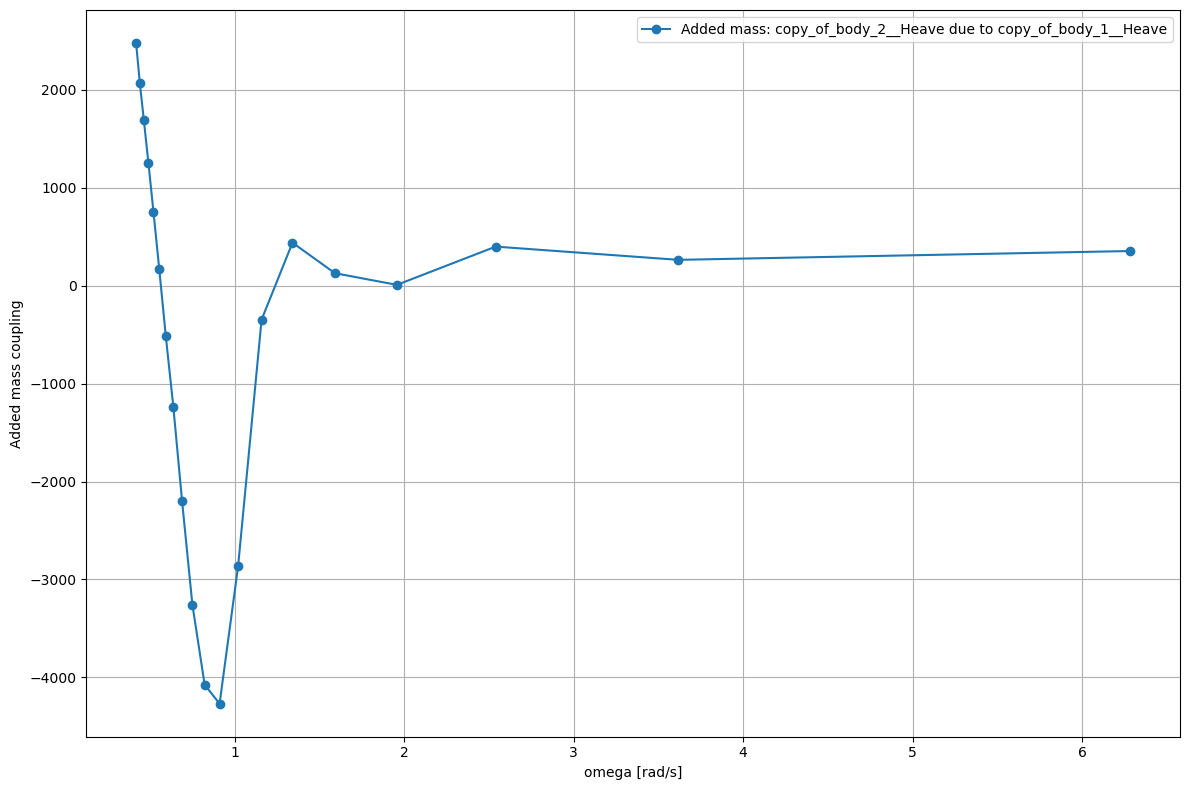

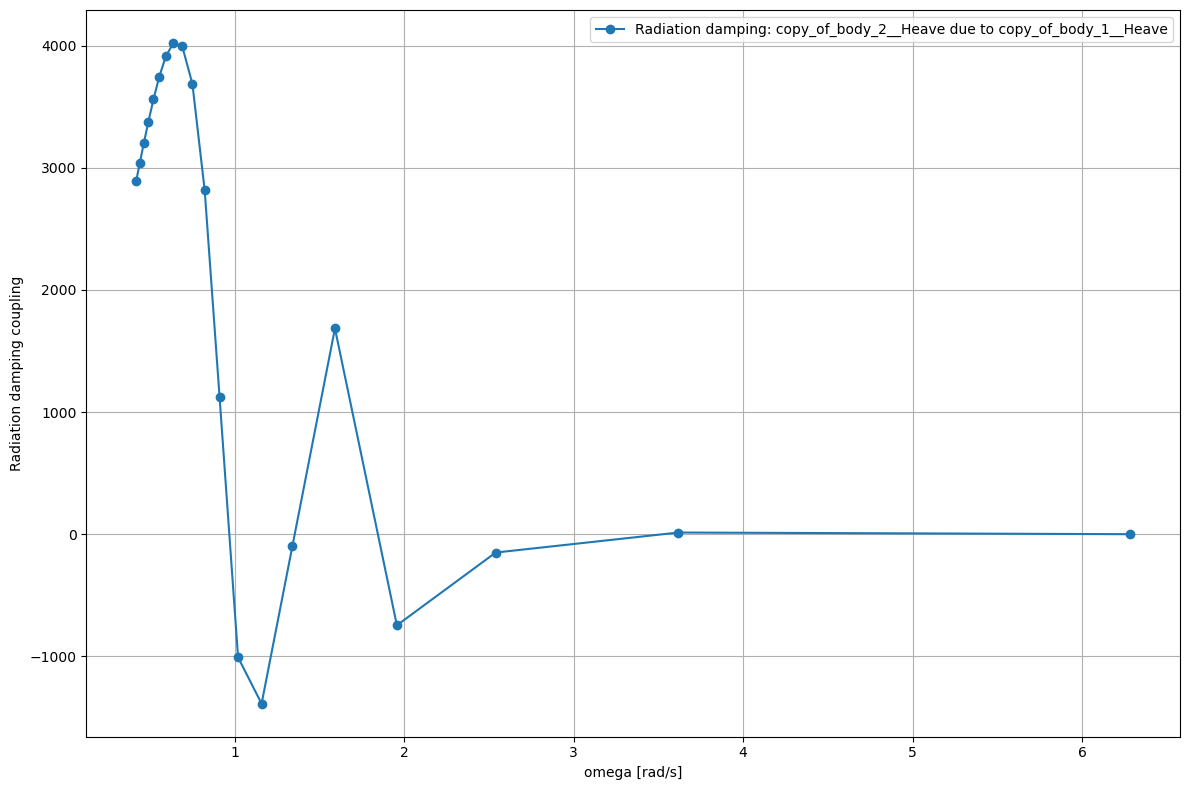

In [22]:
# ============================================================
# BLOCK 13 — Plot example hydrodynamic coupling
# ============================================================

radiating = "copy_of_body_1__Heave"
influenced = "copy_of_body_2__Heave"

A12 = dataset["added_mass"].sel(
    radiating_dof=radiating,
    influenced_dof=influenced,
).squeeze()

B12 = dataset["radiation_damping"].sel(
    radiating_dof=radiating,
    influenced_dof=influenced,
).squeeze()

plt.figure()
plt.plot(dataset["omega"], A12, marker="o", label=f"Added mass: {influenced} due to {radiating}")
plt.xlabel("omega [rad/s]")
plt.ylabel("Added mass coupling")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(dataset["omega"], B12, marker="o", label=f"Radiation damping: {influenced} due to {radiating}")
plt.xlabel("omega [rad/s]")
plt.ylabel("Radiation damping coupling")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [23]:
# ============================================================
# BLOCK E — Check hydrodynamic data needed by WEC-Sim/BEMIO
# ============================================================

required_variables = [
    "added_mass",
    "radiation_damping",
    "diffraction_force",
    "Froude_Krylov_force",
    "excitation_force",
]

print("\n" + "=" * 80)
print("CHECKING CAPYTAINE DATASET FOR WEC-SIM/BEMIO")
print("=" * 80)

print("\nDataset variables:")
for var in dataset.data_vars:
    print("  ", var)

print("\nRequired variables check:")
for var in required_variables:
    if var in dataset:
        print(f"  OK: {var}, shape = {dataset[var].shape}")
    else:
        print(f"  MISSING: {var}")

print("\nDataset coordinates:")
for coord in dataset.coords:
    print(f"  {coord}: {dataset.coords[coord].shape}")

print("\nRadiating DOFs:")
for dof in dataset.coords["radiating_dof"].values:
    print("  ", dof)

print("\nInfluenced DOFs:")
for dof in dataset.coords["influenced_dof"].values:
    print("  ", dof)


CHECKING CAPYTAINE DATASET FOR WEC-SIM/BEMIO

Dataset variables:
   added_mass
   radiation_damping
   diffraction_force
   Froude_Krylov_force
   excitation_force
   inertia_matrix
   hydrostatic_stiffness
   rotation_center
   center_of_mass

Required variables check:
  OK: added_mass, shape = (20, 12, 12)
  OK: radiation_damping, shape = (20, 12, 12)
  OK: diffraction_force, shape = (20, 8, 12)
  OK: Froude_Krylov_force, shape = (20, 8, 12)
  OK: excitation_force, shape = (20, 8, 12)

Dataset coordinates:
  g: ()
  rho: ()
  body_name: ()
  water_depth: ()
  forward_speed: ()
  wave_direction: (8,)
  omega: (20,)
  radiating_dof: (12,)
  influenced_dof: (12,)
  freq: (20,)
  period: (20,)
  wavenumber: (20,)
  wavelength: (20,)
  rigid_body_component: (2,)

Radiating DOFs:
   copy_of_body_1__Surge
   copy_of_body_1__Sway
   copy_of_body_1__Heave
   copy_of_body_1__Roll
   copy_of_body_1__Pitch
   copy_of_body_1__Yaw
   copy_of_body_2__Surge
   copy_of_body_2__Sway
   copy_of_body_2

In [24]:
# ============================================================
# BLOCK H — Compute RAOs for the two-body system
# ============================================================

from capytaine.post_pro import rao

# Make sure the dataset carries the combined matrices
dataset["inertia_matrix"] = two_body.inertia_matrix
dataset["hydrostatic_stiffness"] = two_body.hydrostatic_stiffness

# Compute RAO for one selected wave direction
selected_wave_direction = wave_direction_range[0]

rao_dataset = rao(
    dataset,
    wave_direction=selected_wave_direction,
)

print("\n" + "=" * 80)
print("RAO DATASET")
print("=" * 80)
print(rao_dataset)

           INFO     Compute RAO.


RAO DATASET
<xarray.DataArray (omega: 20, radiating_dof: 12)> Size: 4kB
array([[-3.24354868e-03+1.34243058e+00j,  5.97351888e-05-5.13753762e-05j,
         9.77670105e-01-1.19443792e-04j,  7.59251958e-07-3.86772992e-06j,
         6.23113178e-06-2.77886870e-02j, -4.74133629e-06+3.83510251e-07j,
        -8.51535376e-01+1.03764216e+00j,  8.97779981e-05+2.69137706e-06j,
         7.54301192e-01+6.22036828e-01j,  1.21780084e-06-3.69866523e-06j,
         1.76714709e-02-2.14459665e-02j, -5.01086202e-06-4.56073858e-06j],
       [-3.25359843e-03+1.27374924e+00j,  6.14441380e-05-5.29048215e-05j,
         9.74802079e-01-1.33224208e-04j,  9.75063898e-07-4.10295021e-06j,
         6.58696162e-06-2.96644345e-02j, -4.81855842e-06+6.56384762e-07j,
        -8.49656439e-01+9.48775790e-01j,  9.18882058e-05+6.94834513e-06j,
         7.24545877e-01+6.52200666e-01j,  1.53399575e-06-3.97362444e-06j,
         1.98364102e-02-2.20562282e-02j, -5.03075669e-06-4.69210649e-06j],
       [-3.26988575e-03+1.20451535e+0

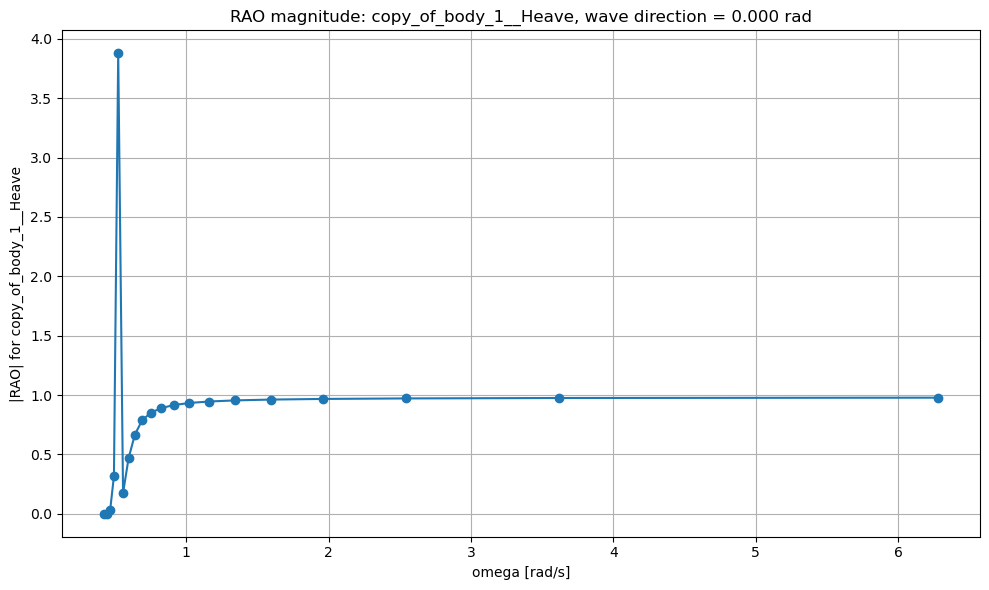

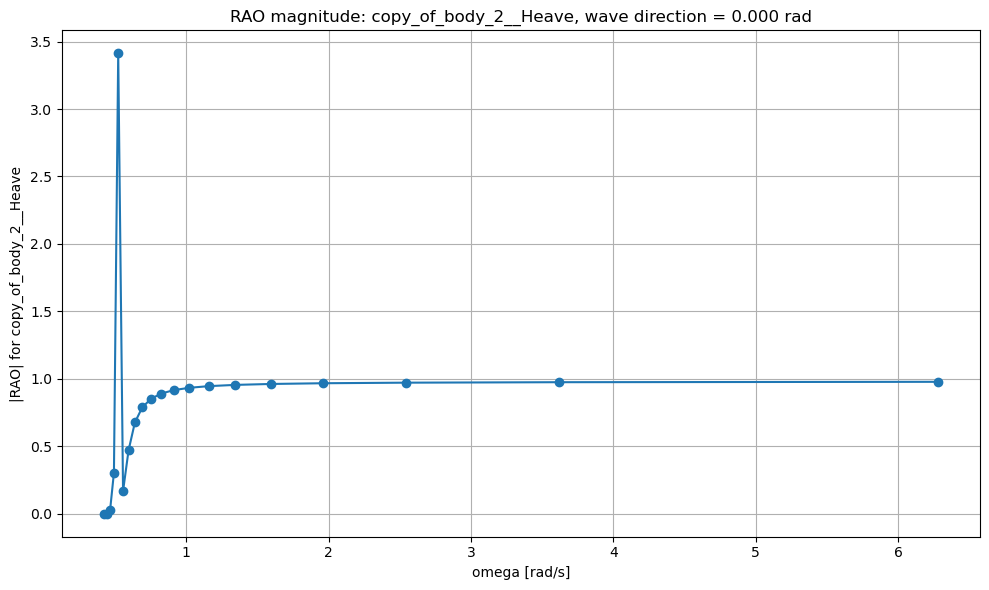

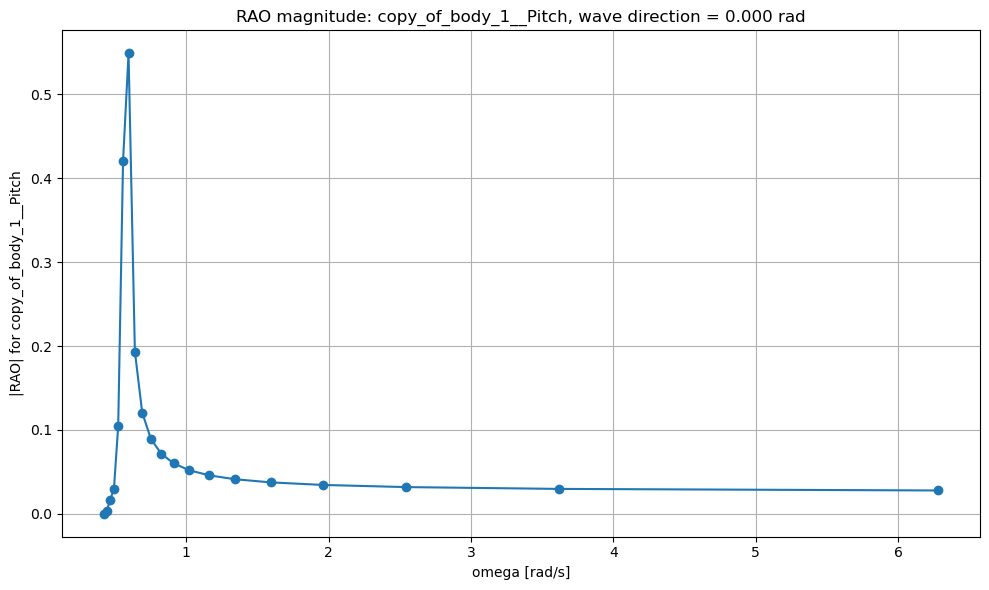

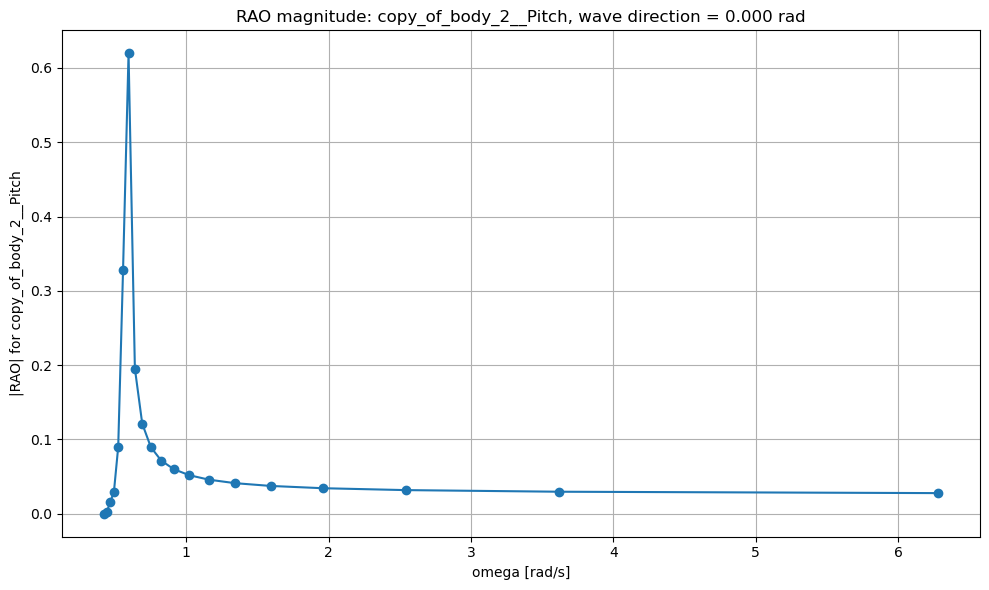

In [25]:
# ============================================================
# BLOCK I — Plot RAO magnitudes
# ============================================================

def plot_rao_magnitude(rao_data, dof_name, output_filename=None):
    """
    Plot RAO magnitude for one DOF.
    """

    # Some Capytaine versions return the RAO as a DataArray,
    # others may wrap it in a Dataset. This handles both.
    if isinstance(rao_data, xr.Dataset):
        if "rao" in rao_data:
            rao_values = rao_data["rao"]
        elif "RAO" in rao_data:
            rao_values = rao_data["RAO"]
        else:
            raise KeyError(f"Could not find RAO variable in dataset. Variables: {list(rao_data.data_vars)}")
    else:
        rao_values = rao_data

    selected = rao_values.sel(radiating_dof=dof_name).squeeze()

    plt.figure(figsize=(10, 6))
    plt.plot(omega_range, np.abs(selected), marker="o")
    plt.xlabel("omega [rad/s]")
    plt.ylabel(f"|RAO| for {dof_name}")
    plt.title(f"RAO magnitude: {dof_name}, wave direction = {selected_wave_direction:.3f} rad")
    plt.grid(True)
    plt.tight_layout()

    if output_filename is not None:
        plt.savefig(os.path.join(output_dir, output_filename), dpi=300)

    plt.show()


plot_rao_magnitude(
    rao_dataset,
    "copy_of_body_1__Heave",
    "rao_body_1_heave.png",
)

plot_rao_magnitude(
    rao_dataset,
    "copy_of_body_2__Heave",
    "rao_body_2_heave.png",
)

plot_rao_magnitude(
    rao_dataset,
    "copy_of_body_1__Pitch",
    "rao_body_1_pitch.png",
)

plot_rao_magnitude(
    rao_dataset,
    "copy_of_body_2__Pitch",
    "rao_body_2_pitch.png",
)